# Exercise 5

### Computer Vision, Fall 2025

#### Name: <font color='blue'>*write your name here*</font>
---
**Instructions:**

- Return the answer in PDF and Jupyter Notebook formats.

- Return latest on<font color='red'> Sunday 12.10.2025 at 23.59</font> via Moodle.


## Ex 5.1. Structure from motion (2 p)
During the lecture you have learned about **structure from motion** (SfM). Please briefly explain:

- a) What is the goal of this technique? (Make sure to specify the inputs and outputs of a basic SfM pipeline.) (1p)

- b) What are the steps of **two-view** SfM? (Base your answer on the lecture slides.) (0.5p)

- c) What is not recoverd with **SfM** and why is that a problem? (0.5p)

**Bonus for the interested:**

One of the applications of SfM is 3D reconstruction of places (buildings, cities, etc.). A famous SfM project is called "Building Rome in a Day", which used 2 million tourists' photos of Rome to construct 3D representations of famous landmarks. If you are interested please visit https://grail.cs.washington.edu/projects/rome/, where you can see videos of the reconstructions. After that you can go to https://waymo.com/research/block-nerf/ and watch a video about 3D reconstruction of San Francisco done with a different novel deep learning technique, called Neural Radiance Fields (NeRF). You can compare for yourself the progress that has been made in slightly more than a decade.

### Answer

a) The goal of structure from motion is to estimate both the 3D shape of a scene and the motion (position and orientation) of the camera that captured it. The input is a set of multiple 2D images of the same scene taken from different viewpoints, and the output is the reconstructed 3D points of the scene together with the estimated camera parameters for each image. Sumamrazing, the algorithm detects and matches visual features across the images, and from these matches SfM reconstructs the 3D coordinates of the points in the scene (the structure) and determines the relative poses of the cameras (the motion).

b) The steps of two-view SfM are:
1. Find point correspondences between the two images  
2. Compute the Fundamental Matrix (F) using the 8-point algorithm  
3. Estimate the camera matrices (P and P') from F  
4. Triangulate the matched points to get their 3D coordinates  

c) SfM cannot recover the absolute scale of the scene, only the relative geometry. This means that the reconstruction can tell how far objects are from each other, but not their real-world distances or sizes (for example, in meters). The problem occurs because when only image data is available, any scaled version of the same 3D scene would produce identical 2D projections. This is an issue for applications such as robot navigation or mapping, where knowing the true scale of the environment is necessary to measure distances or move accurately.

## Ex 5.2. Stereo rectification (2p)
In computer vision, stereo cameras are used to recover depth information, in a process called stereo reconstruction. An important step of this process is **stereo rectification**, which aligns two images to the same plane. During the lecture you have learned a procedure for **stereo rectification** given calibrated cameras. In this exercise you will perform **stereo rectification** for uncalibrated cameras, using OpenCV method `stereoRectifyUncalibrated()` [OpenCV documentation link](https://docs.opencv.org/3.4/d9/d0c/group__calib3d.html#gaadc5b14471ddc004939471339294f052:~:text=%E2%97%86-,stereoRectifyUncalibrated,-()).

Tasks:

- a) You are provided with code that performs stereo rectification. Some parts of the code have been removed. Fill in the missing parts. You can use provided helper methods and OpenCV methods. (1.5p)
- b) Answer the questions: what happens to epipolar lines after stereo rectification? Why is that useful for stereo reconstruction?

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [34]:
# Helper methods, do not modify
def plot_imgs(img1, img2):
    """Plot two images side by side.
    Args:
        img1 - first image to plot
        img2 - second image to plot
    """
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # Display the first image
    axes[0].imshow(img1)
    axes[0].axis('off')  # Turn off axis for better visualization
    axes[0].set_title('Image 1')

    # Display the second image
    axes[1].imshow(img2)
    axes[1].axis('off')  # Turn off axis for better visualization
    axes[1].set_title('Image 2')

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

def get_keypoints(gray1, gray2):
    """Detect and match keypoints in two grayscale images.
    Args:
        gray1 - first grayscale image
        gray2 - second grayscale image
    """
    # Detect and compute features (ORB for simplicity)
    orb = cv2.ORB_create(5000)
    kp1, des1 = orb.detectAndCompute(gray1, None)
    kp2, des2 = orb.detectAndCompute(gray2, None)

    # Match features
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Extract matched keypoints
    pts1 = np.float32([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in matches])

    return pts1, pts2

def visualize_epipolar_lines(img1, img2, pts1, pts2, fundamental_matrix):
    """Find and draw epipolar lines on the images.
    Args:
        img1 - left image from the stereo pair
        img2 - right image from the stereo pair
        pts1 - keypoints in the left image
        pts2 - keypoints in the right image
        fundamental_matrix - computed fundamental matrix
    """
    
    def drawlines(img1, img2, lines, pts1, pts2):
        r, c, _ = img1.shape       
        # Use the same random seed so that two images are comparable!
        np.random.seed(0)
        for r, pt1, pt2 in zip(lines, np.int32(pts1), np.int32(pts2)):
            color = tuple(np.random.randint(0, 255, 3).tolist())
            x0, y0 = map(int, [0, -r[2]/r[1]])
            x1, y1 = map(int, [c, -(r[2]+r[0]*c)/r[1]])
            img1 = cv2.line(img1, (x0, y0), (x1, y1), color, 1)
            img1 = cv2.circle(img1, tuple(pt1), 5, color, -1)
            img2 = cv2.circle(img2, tuple(pt2), 5, color, -1)
        return img1, img2

    lines1 = cv2.computeCorrespondEpilines(
        pts2.reshape(-1, 1, 2), 2, fundamental_matrix)
    lines1 = lines1.reshape(-1, 3)
    img1_with_epi, _ = drawlines(img1, img2, lines1, pts1, pts2)

    # Find epilines corresponding to points in left image (first image) and
    # drawing its lines on right image
    lines2 = cv2.computeCorrespondEpilines(
        pts1.reshape(-1, 1, 2), 1, fundamental_matrix)
    lines2 = lines2.reshape(-1, 3)
    img2_with_epi, _ = drawlines(img2, img1, lines2, pts2, pts1)

    return img1_with_epi, img2_with_epi

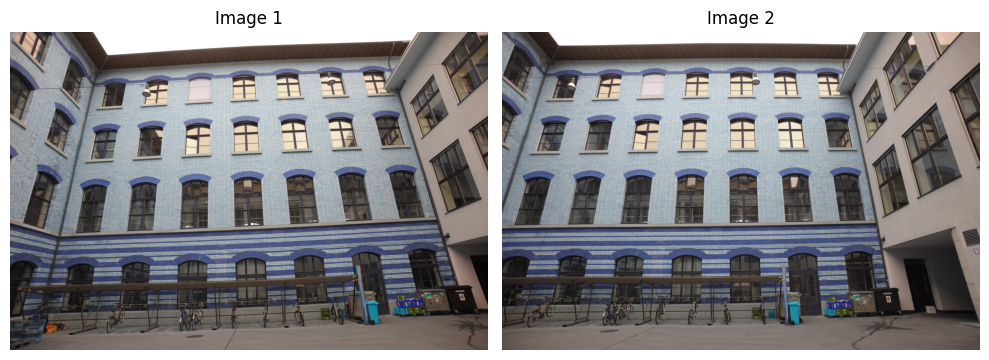

In [35]:
# Initialization code, do not modify
# 1. Load stereo images
img1 = cv2.imread('courtyard_left.JPG')
img2 = cv2.imread('courtyard_right.JPG')
plot_imgs(img1, img2)

# 2. Convert to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

### a)

Write your code in cells below

Computed Homography H1:
[[ 6.22091366e-03 -3.91371464e-04  1.36797606e+00]
 [ 2.05445411e-04  7.27798781e-03 -8.41157898e-01]
 [-4.71130939e-08  2.13492721e-09  7.45252283e-03]]
Computed Homography H2:
[[ 9.75931148e-01 -8.52051754e-03  8.99615727e+01]
 [-7.29017322e-03  1.00010176e+00  2.18403368e+01]
 [-7.94667404e-06  6.93796644e-08  1.02389087e+00]]


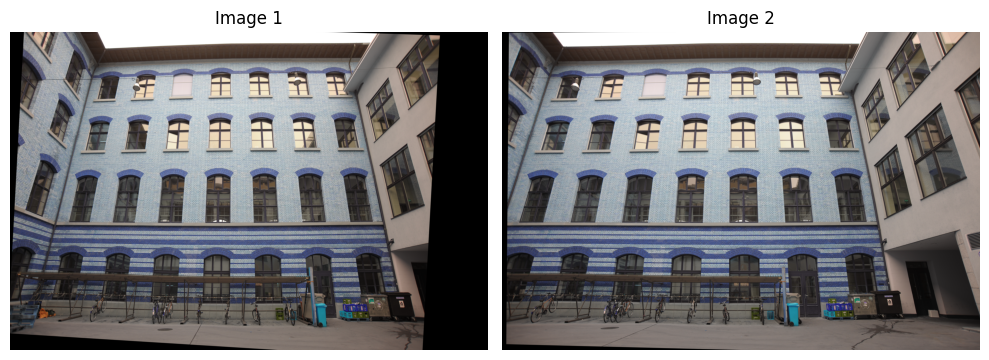

In [36]:
# 3. Get matched keypoints
pts1, pts2 = get_keypoints(gray1, gray2)

# 4. Compute Fundamental Matrix
fundamental_matrix, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC, 3.0, 0.99)
pts1_inliers = pts1[mask.ravel() == 1]
pts2_inliers = pts2[mask.ravel() == 1]

# 5. Find rectification transforms (homographies) from uncalibrated cameras
h, w = img1.shape[:2]
retval, H1, H2 = cv2.stereoRectifyUncalibrated(pts1_inliers, pts2_inliers, fundamental_matrix, (w, h))

# 6. Undistort (rectify) the images
#apply the homographies using cv2.warpPerspective
img1_rectified = cv2.warpPerspective(img1, H1, (w, h))
img2_rectified = cv2.warpPerspective(img2, H2, (w, h))

# 7. Display results
print(f"Computed Homography H1:\n{H1}")
print(f"Computed Homography H2:\n{H2}")

plot_imgs(img1_rectified, img2_rectified)


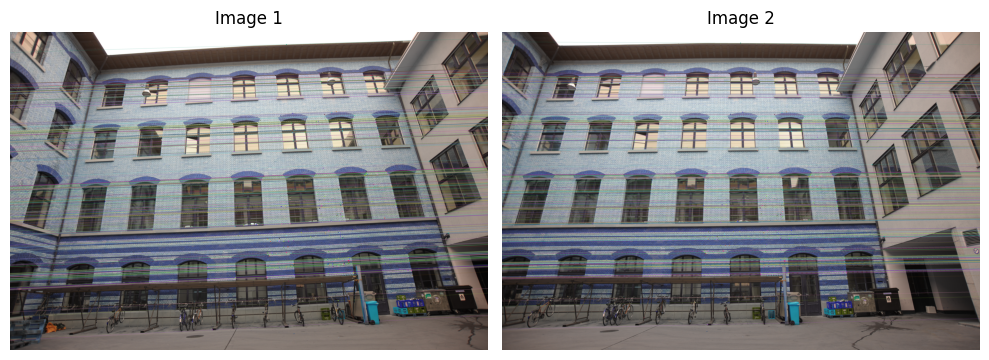

In [37]:
# 8. Plot epipolar lines on original images
img1_epi, img2_epi = visualize_epipolar_lines(img1.copy(), img2.copy(), pts1_inliers, pts2_inliers, fundamental_matrix)
plot_imgs(img1_epi, img2_epi)

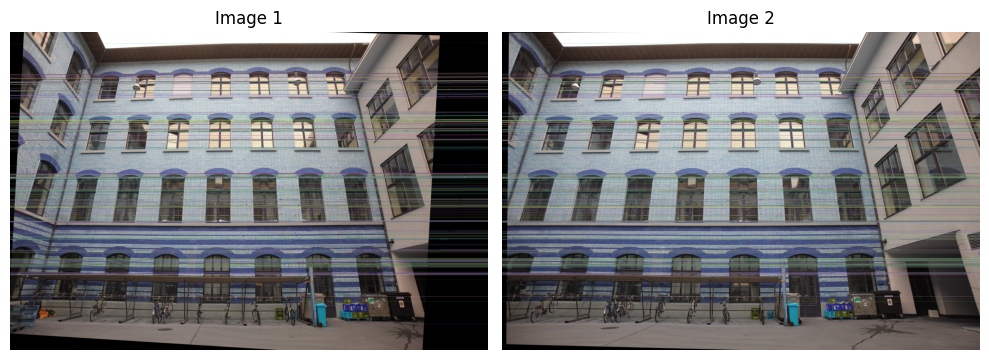

In [38]:
# 9. Visualize epipolar lines on rectified images
# Hint: Think carefully about the order of the operations performed, so that the epipolar lines are drawn correctly.

pts1_rect = cv2.perspectiveTransform(pts1_inliers.reshape(-1, 1, 2), H1).reshape(-1, 2)
pts2_rect = cv2.perspectiveTransform(pts2_inliers.reshape(-1, 1, 2), H2).reshape(-1, 2)

#Fundamental Matrix for the rectified points
F_rect, _ = cv2.findFundamentalMat(pts1_rect, pts2_rect, cv2.FM_8POINT)

#epipolar lines using the rectified images, rectified points, and F_rect
img1_rect_epi, img2_rect_epi = visualize_epipolar_lines(
    img1_rectified.copy(), 
    img2_rectified.copy(), 
    pts1_rect[:3000],  # Use a subset of points for visualization
    pts2_rect[:3000],
    F_rect
)

# Display the rectified images with epipolar lines
plot_imgs(img1_rect_epi, img2_rect_epi)


### Answers
b) After stereo rectification, the epipolar lines become almost perfectly horizontal and aligned across the two images. This means that corresponding points in the left and right images lie on the same horizontal line. 
This is useful for stereo reconstruction because it simplifies the search for matching points, instead of searching in 2D over the entire image, we only need to search along the same row in the second image, which makes computing disparities and depth much faster and more accurate.

## Ex 5.3 Optical flow (2p)
Optical flow is a method used to measure pixel movement between frames. During the lecture you have learned about two different methods for finding the optical flow - **Horn-Schunck** and **Lucas-Kanade**.

Task:

a) Explain the main differences between the Horn-Schunck and Lucas-Kanade methods. Please mention the main assumptions behind each method. (2p)


### Answers

a) Horn-Schunck and Lucas-Kanade are two foundational methods for calculating optical flow, but they tackle the problem using fundamentally different approach. Horn-Schunck is a dense and global methot that tries to estimate the movement for every single pixel in the image. It relies on two key assumptions: brightness constancy (the intensity of a pixel doesn't change between frames) and smoothness (the entire motion field must be continuous and smooth across the image). Because it minimizes a global energy function, Horn-Schunck produces a continuous flow field, even in textureless areas, but this global averaging can make it sensitive to noise and inaccurate where motion is actually discontinuous. Lucas-Kanade, on the other hand, is a sparse and local method. It focuses only on tracking a few, distinctive features, typically relying on the brightness constancy assumption and the critical assumption that the optical flow is constant only within a small patch of pixels. By solving for motion locally, Lucas-Kanade is generally much faster and more robust in areas with good texture, accurately tracking those specific points. However, because it's local and sparse, it fails completely in uniform, textureless regions and cannot provide a complete picture of the motion across the entire frame. Essentially, Horn-Schunck aims for a globally smooth, complete (dense) picture of motion, while Lucas-Kanade prioritizes highly accurate local estimates (sparse flow) only where the image features allow for reliable measurement.

## Ex 5.4 Lucas-Kanade method (2p)
In this exercise your task is to implement **Lucas-Kanade method** and apply it to one provided video and one your own video.

Tasks:

a) Implement the **Lucas-Kanade method**. Put your code inside the function provided below. The function should save video with visualized flow and return last frame of the video. Feel free to use code from OpenCV [tutorial on optical flow](https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html). (0.75p)

b) Apply your implemented function to provided video **Swan.mp4**. Save the resulting video to file **Swan_OF.avi** and upload it to moodle with your answer. Plot the last frame. (0.25p)

c) Record a short video (<5sec) in which **Lucas-Kanade method** fails (*Hint: Think about the assumptions of the method and try to break them*). Apply your implemented function to the video. Save the resulting video and upload it to moodle with you answer. Plot the last frame. Write why the method fails on your video? (1p)

In [43]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

### a)

In [44]:
def LK_optical_flow(video_path, output_path='output.avi'):
    """Lucas-Kanade optical flow implementation.
    Code based on: https://docs.opencv.org/3.4/d4/dee/tutorial_optical_flow.html
    Args:
        video_path - path to the video file
        output_path - path to save the output video with optical flow visualization
    Returns:
        last_frame - the last frame of the video with optical flow visualization
    """
    
# Video Capture and Initialization
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    #video properties 
    ret, old_frame = cap.read()
    if not ret:
        print("Error: Could not read first frame.")
        return None
        
    frame_height, frame_width = old_frame.shape[:2]
    fps = cap.get(cv2.CAP_PROP_FPS)
    
    # Define the codec and create VideoWriter object
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    
    #Parameters 
    feature_params = dict(
        maxCorners = 100,      # Max number of corners to return
        qualityLevel = 0.3,    # Minimum accepted quality of image corners
        minDistance = 7,       # Minimum Euclidean distance between corners
        blockSize = 7          # Size of an average block for computing a derivative
    )

    #Parameters for Lucas-Kanade Optical Flow
    lk_params = dict(
        winSize  = (15, 15),   # Size of the search window
        maxLevel = 2,          # Max level of the pyramid 
        criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    #initial feature points 
    p0 = cv2.goodFeaturesToTrack(old_gray, mask = None, **feature_params)

    #mask image for drawing tracks
    mask = np.zeros_like(old_frame)
    
    #random colors for points and tracks
    color = np.random.randint(0, 255, (feature_params['maxCorners'], 3)).tolist()

    #Video Frames
    while(cap.isOpened()):
        ret, frame = cap.read()
        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calculate optical flow 
        #implements the Lucas-Kanade method
        p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None, **lk_params)

        #good points 
        if p1 is not None:
            good_new = p1[st == 1]
            good_old = p0[st == 1]
            
            #draw the tracks
            for i, (new, old) in enumerate(zip(good_new, good_old)):
                a, b = map(int, new.ravel())
                c, d = map(int, old.ravel())
                
                #draw line )
                mask = cv2.line(mask, (a, b), (c, d), color[i], 2)
                
                #draw circle 
                frame = cv2.circle(frame, (a, b), 5, color[i], -1)

            #combine the current frame and the track mask
            img = cv2.add(frame, mask)

            #frame to the output video
            out.write(img)

            #update the previous frame and points for the next iteration
            old_gray = frame_gray.copy()
            
            #the new points become the old points for the next frame
            #re-detect new features if too few points are tracked
            if len(good_new) < feature_params['maxCorners'] / 2:
                p0 = cv2.goodFeaturesToTrack(old_gray, mask = None, **feature_params)
            else:
                p0 = good_new.reshape(-1, 1, 2)
        else:
            # If tracking fails completely
            p0 = cv2.goodFeaturesToTrack(frame_gray, mask = None, **feature_params)
            old_gray = frame_gray.copy()
            img = frame
            
    cap.release()
    out.release()
    cv2.destroyAllWindows()
    
    #last processed frame
    return img


### b)

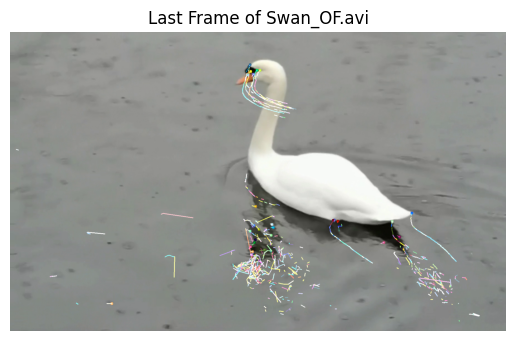

Video saved to Swan_OF.avi


In [45]:
# Apply your implemented function to Swan.mp4
video_path_swan = 'Swan.mp4'
output_path_swan = 'Swan_OF.avi'
last_frame_swan = LK_optical_flow(video_path_swan, output_path_swan)
# Plot the last frame
if last_frame_swan is not None:
     last_frame_rgb = cv2.cvtColor(last_frame_swan, cv2.COLOR_BGR2RGB)
     plt.imshow(last_frame_rgb)
     plt.title(f"Last Frame of {output_path_swan}")
     plt.axis('off')
     plt.show()

print(f"Video saved to {output_path_swan}")

### c)

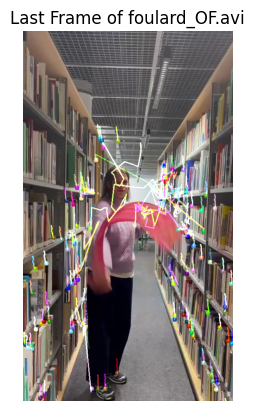

Video saved to foulard_OF.avi


In [46]:
# Apply your implemented function to your own video
video_path = 'foulard.mp4'
output_path = 'foulard_OF.avi'
last_frame = LK_optical_flow(video_path, output_path)
# Plot the last frame
if last_frame is not None:
     last_frame_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)
     plt.imshow(last_frame_rgb)
     plt.title(f"Last Frame of {output_path}")
     plt.axis('off')
     plt.show()

print(f"Video saved to {output_path}")

### Answers

In the video, I move and rotate a non-rigid object (a foulard) between some library shelves. I have used the Lucas-Kanade method to track this movement, but the flow lines show that it does not work correctly.  

The Lucas-Kanade method fails mainly because the foulard breaks the spatial coherence assumption. LK assumes that all pixels in a small patch move in the same direction and speed, but since the foulard is non-rigid different parts move in different directions at the same time, for example one part goes up while another part goes down or sideways. The algorithm tries to find one motion vector that fits all the pixels in the patch, so it cannot track the movement correctly.  
Also, the rapid rotation and deformation of the foulard make it hard for the algorithm to match points from frame to frame. Because LK is a local method, it cannot use information from the rest of the image to correct errors. As a result, the flow lines are incorrect, and the motion of the foulard is not captured well. This shows a clear limitation of Lucas-Kanade when dealing with fast or non-rigid motion.

# Sources
- Slides for lectures 9 and 10
- Data for stereo rectification: https://www.eth3d.net/datasets, which is available under a license https://creativecommons.org/licenses/by-nc-sa/4.0/
- https://visionbook.mit.edu/multiview.html
- https://www.andreasjakl.com/understand-and-apply-stereo-rectification-for-depth-maps-part-2/


